In [51]:
from data_prep import tokenize, vocabulary, tfidf_sparse, plot_sentiment_distribution, plot_cloud, bar_top_words, plot_confusion_matrix
from logistic_regression import train_lr, predict_lr, compute_loss, predict_new_sentence
from svm import train_svm, predict_svm
import pandas as pd
import numpy as np
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt

data = pd.read_csv("data.csv")
print(data.head())

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


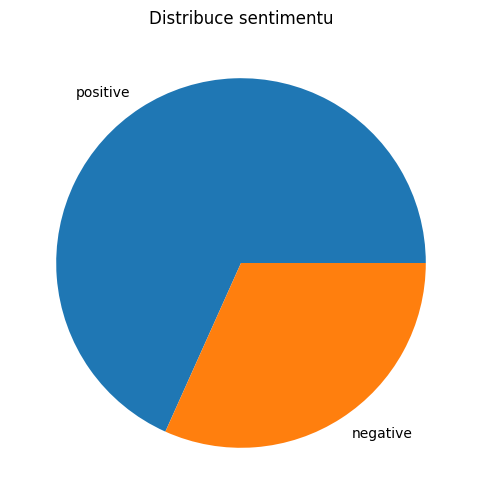

                                            Sentence Sentiment  Label
0                   $FB watching for bounce tomorrow  positive      1
1  Earnings per share for the quarter were also h...  positive      1
2  Operating profit totalled EUR 5.8 mn , up from...  positive      1
3  `` We are pleased with the efforts of both neg...  positive      1
4  The sale , which will result in a gain of some...  positive      1


In [2]:
data = data[data["Sentiment"] != "neutral"]
data = data.sample(frac=1).reset_index(drop=True)
data['Label'] = data['Sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
plot_sentiment_distribution(data)
print(data.head())

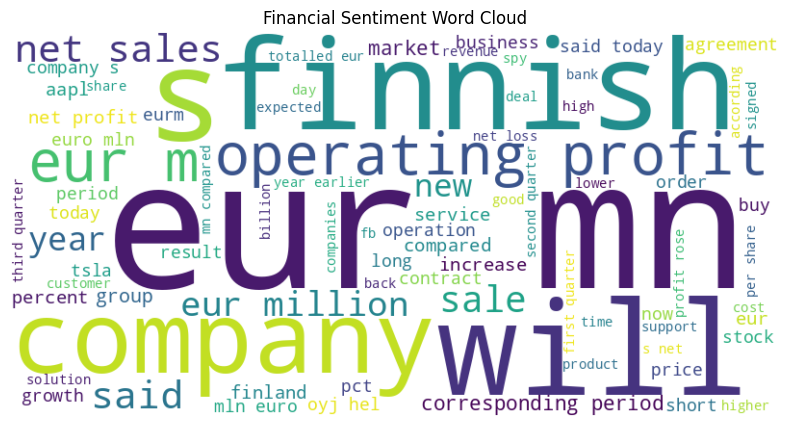

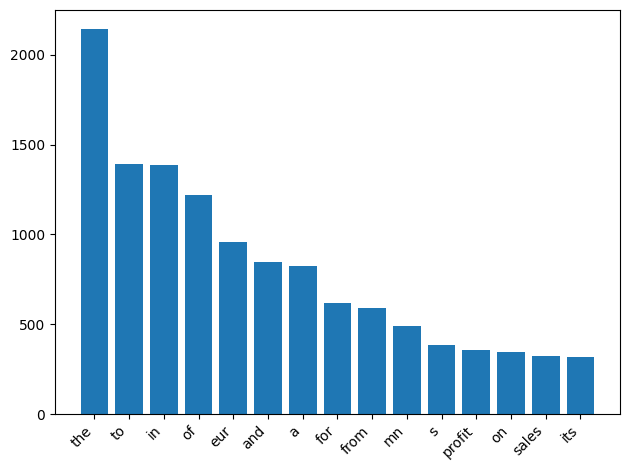

In [3]:
data["Cleaned_tokens"] = data["Sentence"].apply(tokenize)
corpus = data["Cleaned_tokens"].tolist()

plot_cloud(corpus)
bar_top_words(15, corpus)
#Potreba ocistit o stop words

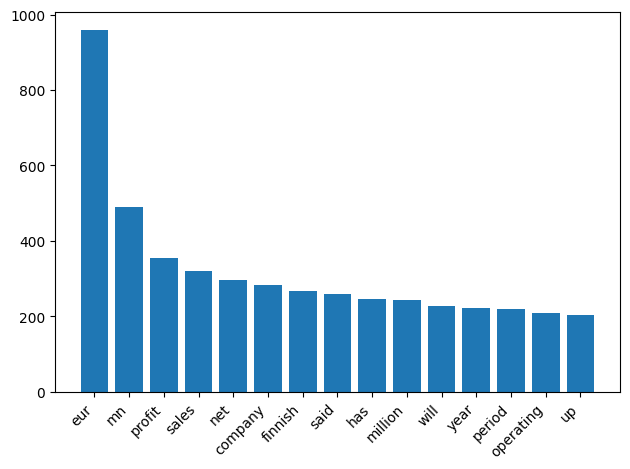

In [4]:
stop_words = ["the", "is", "at", "which", "on", "and", "a", "to", "in", "of", "for", "with", "as", "by", "that", "this", "it", "from", "are", "was", "be", "or", "an", "not", "all", "but", "if", "they", "their", "we", "he", "she", "my", "your", "his", "her", "its", "our", "us", "them", "what", "who", "whom", "which", "whose", "when", "where", "why", "how", "s"]

corpus = [[token for token in doc if token not in stop_words] for doc in corpus]
bar_top_words(15, corpus)

In [5]:
split_idx = int(len(corpus) * 0.8)

X_train = corpus[:split_idx] 
X_test = corpus[split_idx:]
y_train = data["Label"][:split_idx].to_numpy()
y_test = data["Label"][split_idx:].to_numpy()

train_vocab = vocabulary(X_train)

train_tfidf, idf = tfidf_sparse(X_train, train_vocab)
test_tfidf, _ = tfidf_sparse(X_test, train_vocab, idf)

In [6]:
learning_rate = 0.1
epochs = 30_000
lambda_reg = 0.1

weight_0 = len(y_train) / (2 * np.sum(y_train == 0))
weight_1 = len(y_train) / (2 * np.sum(y_train == 1))


weights, bias = train_lr(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1)

Epoch 0, Loss: 0.6931
Epoch 3000, Loss: 0.4986
Epoch 6000, Loss: 0.4030
Epoch 9000, Loss: 0.3438
Epoch 12000, Loss: 0.3029
Epoch 15000, Loss: 0.2726
Epoch 18000, Loss: 0.2492
Epoch 21000, Loss: 0.2304
Epoch 24000, Loss: 0.2150
Epoch 27000, Loss: 0.2021


In [7]:
y_probs = predict_lr(test_tfidf, weights, bias)
test_loss = compute_loss(y_test, y_probs)

y_classes = (y_probs >= 0.5).astype(int)
accuracy = np.mean(y_classes == y_test)

print(f"Test Loss (LogLoss): {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

Test Loss (LogLoss): 0.3965
Test Accuracy: 83.98%


In [8]:
print(predict_new_sentence("The unexpected resignation of the CEO caused a sharp drop in share prices.", train_vocab,weights, bias, idf))

0.39555421386824907


In [9]:
sorted_indices = np.argsort(weights)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

Top 10 Positive Words: 
  up: 4.9551
  rose: 4.7018
  increase: 3.5424
  increased: 3.2545
  long: 2.8476
  grew: 2.6625
  buy: 2.1943
  improved: 2.1354
  business: 1.9288
  rise: 1.8983
Top 10 Negative Words: 
  down: -7.1077
  decreased: -6.0370
  fell: -4.6208
  lower: -3.7948
  short: -3.2592
  fall: -3.0733
  declined: -2.9559
  dropped: -2.9340
  cut: -2.5311
  weak: -2.2786


Precision: 0.8601
Recall: 0.9096
F1 Score: 0.8842


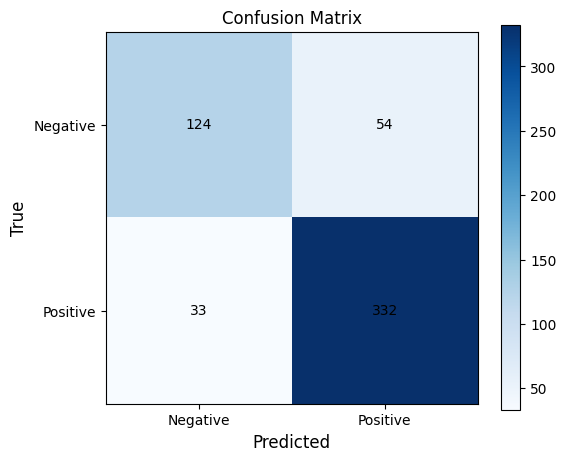

In [10]:
plot_confusion_matrix(y_test, y_classes)

Epoch 0, Loss: 1.000000000004281
Epoch 10000, Loss: 0.6175137144792396
Epoch 20000, Loss: 0.4111702862156699
Epoch 30000, Loss: 0.29900328930063386
Epoch 40000, Loss: 0.23155263767075562
Epoch 50000, Loss: 0.1890581261787341
Epoch 60000, Loss: 0.1581903749993747
Epoch 70000, Loss: 0.1349075877860255
Epoch 80000, Loss: 0.11740959471777887
Epoch 90000, Loss: 0.10320414475679394
SVM Test Accuracy: 83.43%
Precision: 0.8590
Recall: 0.9014
F1 Score: 0.8797


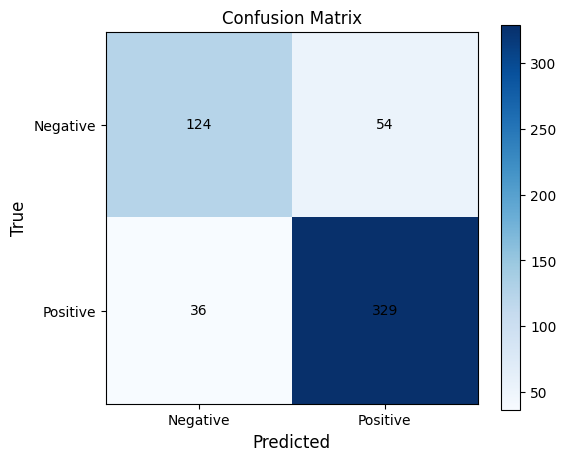

In [11]:
learning_rate = 0.01
epochs = 100_000
lambda_reg = 0.00001


w_svm, b_svm = train_svm(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1,logging=True)

y_svm = predict_svm(test_tfidf, w_svm, b_svm)
print(f"SVM Test Accuracy: {np.mean(y_svm == y_test):.2%}")
plot_confusion_matrix(y_test, y_svm)

In [12]:
sorted_indices = np.argsort(w_svm)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

Top 10 Positive Words: 
  up: 3.1911
  rose: 3.0645
  increase: 2.2230
  increased: 2.1402
  grew: 1.7312
  narrowed: 1.5586
  long: 1.4473
  improved: 1.3838
  positive: 1.2018
  higher: 1.1665
Top 10 Negative Words: 
  down: -3.9497
  decreased: -3.6376
  fell: -3.0661
  lower: -2.2635
  declined: -2.1175
  dropped: -2.0471
  short: -2.0436
  fall: -1.9888
  compared: -1.7714
  drop: -1.7640


LA Test Accuracy: 71.64%
Precision: 0.9011
Recall: 0.6493
F1 Score: 0.7548


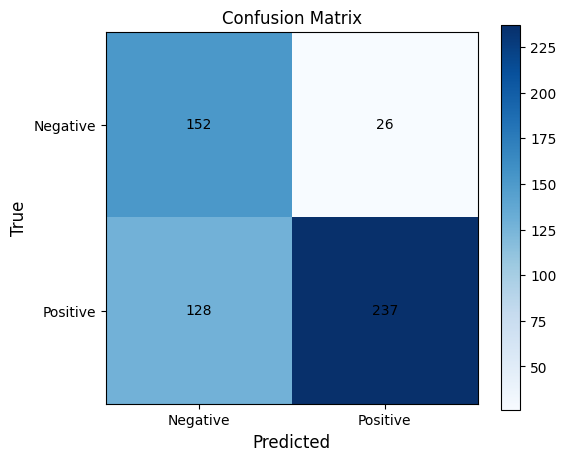

In [ ]:
train_tfidf = train_tfidf.tocsr()
test_tfidf = test_tfidf.tocsr()

avg_pos = np.asarray(train_tfidf[y_train == 1].mean(axis=0)).flatten()
avg_neg = np.asarray(train_tfidf[y_train == 0].mean(axis=0)).flatten()

scores_pos = test_tfidf.dot(avg_pos)
scores_neg = test_tfidf.dot(avg_neg)

y_pred_la = np.where(scores_pos > scores_neg, 1, 0)
accuracy_la = np.mean(y_pred_la == y_test)
print(f"LA Test Accuracy: {accuracy_la:.2%}")

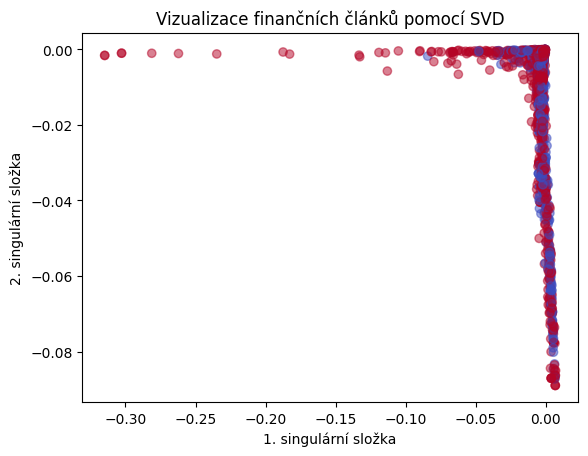

In [61]:
u, s, vt = svds(train_tfidf.toarray(), k = 2)


plt.scatter(u[:, 0], u[:, 1], c=y_train, cmap='coolwarm', alpha=0.5)
plt.title("Vizualizace finančních článků pomocí SVD")
plt.xlabel("1. singulární složka")
plt.ylabel("2. singulární složka")
plt.show()